In [1]:
import pandas as pd
df=pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/Consumer-Complaint-Intelligence/data/processed/cfpb_cleaned_2021_2026.parquet")

In [3]:
print(df.shape)
print(df.isnull().sum().sort_values(ascending=False))

(15741615, 20)
date_received                   0
product                         0
sub_product                     0
issue                           0
sub_issue                       0
company_public_response         0
company                         0
state                           0
zip_code                        0
tags                            0
submitted_via                   0
date_sent_to_company            0
company_response_to_consumer    0
timely_response                 0
complaint_id                    0
year                            0
month                           0
quarter                         0
day_of_week                     0
response_days                   0
dtype: int64


In [4]:
df.head()

,date_received,product,sub_product,issue,sub_issue,company_public_response,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,year,month,quarter,day_of_week,response_days
0,2023-10-02,Mortgage,Conventional home mortgage,Trouble during payment process,Trying to communicate with the company to fix ...,No public response,"CARRINGTON MORTGAGE SERVICES, LLC",GA,30125,Not provided,Web,2023-10-02,Closed with explanation,Yes,7622067,2023,10,4,Monday,0
1,2023-10-09,Mortgage,Conventional home mortgage,Incorrect information on your report,Account status incorrect,Company believes complaint represents an oppor...,HOMESTAR FINANCIAL CORPORATION,GA,30125,Not provided,Web,2023-10-09,Closed with explanation,Yes,7668706,2023,10,4,Monday,0
2,2023-12-09,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Trying to communicate with the company to fix ...,No public response,"CARRINGTON MORTGAGE SERVICES, LLC",GA,30125,Not provided,Web,2023-12-09,Closed with explanation,Yes,7975149,2023,12,4,Saturday,0
3,2024-05-06,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,No public response,"EQUIFAX, INC.",GA,30214,Not provided,Web,2024-05-06,Closed with non-monetary relief,Yes,8939864,2024,5,2,Monday,0
4,2024-06-17,Checking or savings account,Checking account,Managing an account,Problem accessing account,Company has responded to the consumer and the ...,M&T BANK CORPORATION,NY,14541,Not provided,Phone,2024-06-17,Closed with explanation,Yes,9277756,2024,6,2,Monday,0


In [5]:
df.columns.to_list()

['date_received',
 'product',
 'sub_product',
 'issue',
 'sub_issue',
 'company_public_response',
 'company',
 'state',
 'zip_code',
 'tags',
 'submitted_via',
 'date_sent_to_company',
 'company_response_to_consumer',
 'timely_response',
 'complaint_id',
 'year',
 'month',
 'quarter',
 'day_of_week',
 'response_days']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15741615 entries, 0 to 15741614
Data columns (total 20 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   date_received                 datetime64[ns]
 1   product                       object        
 2   sub_product                   object        
 3   issue                         object        
 4   sub_issue                     object        
 5   company_public_response       object        
 6   company                       object        
 7   state                         object        
 8   zip_code                      object        
 9   tags                          object        
 10  submitted_via                 object        
 11  date_sent_to_company          datetime64[ns]
 12  company_response_to_consumer  object        
 13  timely_response               object        
 14  complaint_id                  int64         
 15  year                          

In [8]:
df.nunique().sort_values(ascending=False)

,0
complaint_id,15741615
zip_code,31244
company,6110
date_received,1826
date_sent_to_company,1826
response_days,292
sub_issue,214
issue,95
state,64
sub_product,59


In [9]:
print("Invalid dates:", df["date_received"].isna().sum())

Invalid dates: 0


In [10]:
print("Date range:", df["date_received"].min().date(),
      "to", df["date_received"].max().date())

Date range: 2021-09-26 to 2026-09-26


**Complaint trends over time**

In [11]:
yearly_complaints = (
    df.groupby("year")
      .size()
      .reset_index(name="complaint_count")
)

yearly_complaints

,year,complaint_count
0,2021,131086
1,2022,800245
2,2023,1292049
3,2024,2734269
4,2025,5442963
5,2026,5341003


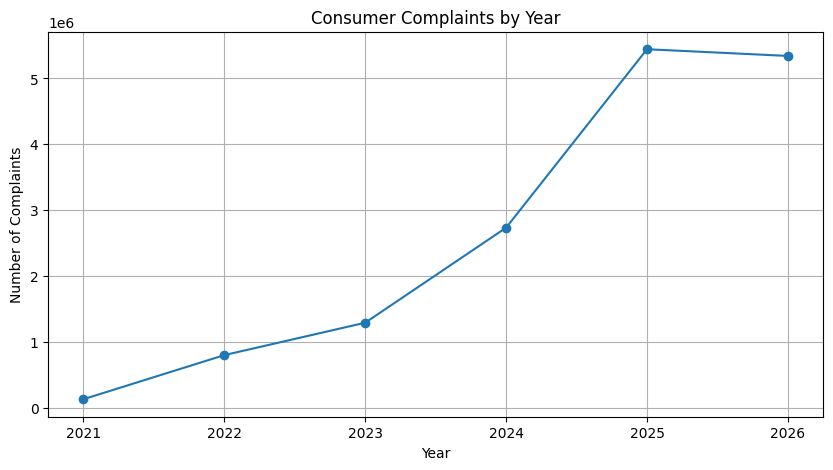

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    yearly_complaints["year"],
    yearly_complaints["complaint_count"],
    marker="o"
)

plt.title("Consumer Complaints by Year")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.grid(True)
plt.show()

**Monthly trend**

In [13]:
monthly_complaints = (
    df.groupby(df["date_received"].dt.to_period("M"))
      .size()
      .reset_index(name="complaint_count")
)

monthly_complaints["date"] = monthly_complaints["date_received"].dt.to_timestamp()

monthly_complaints.head()

,date_received,complaint_count,date
0,2021-09,6795,2021-09-01
1,2021-10,39295,2021-10-01
2,2021-11,39069,2021-11-01
3,2021-12,45927,2021-12-01
4,2022-01,53229,2022-01-01


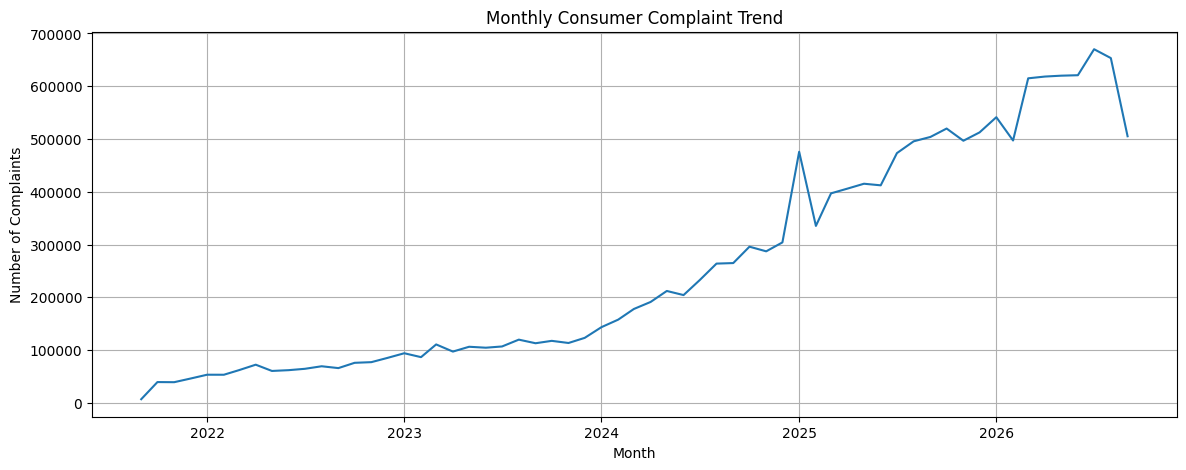

In [14]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_complaints["date"],
    monthly_complaints["complaint_count"]
)

plt.title("Monthly Consumer Complaint Trend")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.grid(True)
plt.show()

**Product analysis**

In [15]:
product_counts = (
    df["product"]
    .value_counts()
    .reset_index()
)
product_counts.columns = ["product", "complaint_count"]

product_counts.head(15)

,product,complaint_count
0,Credit reporting or other personal consumer re...,12443556
1,"Credit reporting, credit repair services, or o...",1331910
2,Debt collection,818486
3,Checking or savings account,297152
4,Credit card,257213
5,"Money transfer, virtual currency, or money ser...",159337
6,Mortgage,123242
7,Credit card or prepaid card,83982
8,Vehicle loan or lease,75925
9,Student loan,70833


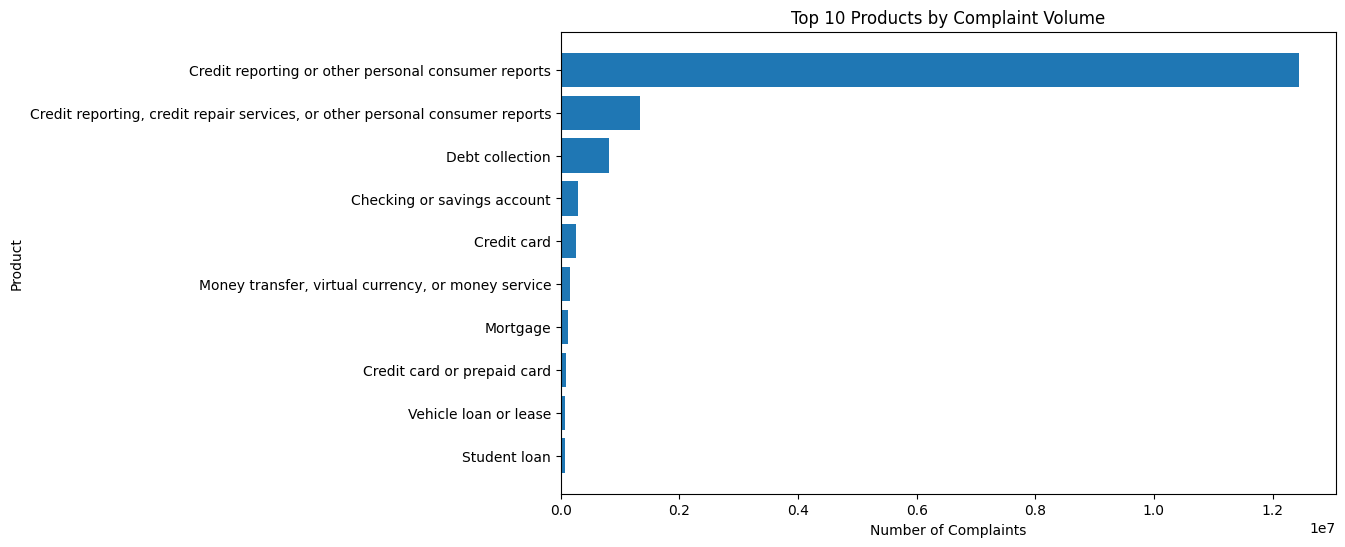

In [16]:
top_products = product_counts.head(10).sort_values("complaint_count")

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["product"],
    top_products["complaint_count"]
)

plt.title("Top 10 Products by Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.show()

**Issue analysis**

In [17]:
issue_counts = (
    df["issue"]
    .value_counts()
    .reset_index()
)
issue_counts.columns = ["issue", "complaint_count"]

issue_counts.head(15)

,issue,complaint_count
0,Incorrect information on your report,7644268
1,Improper use of your report,3364111
2,Problem with a company's investigation into an...,2357472
3,Attempts to collect debt not owed,370657
4,Problem with a credit reporting company's inve...,368407
5,Written notification about debt,177070
6,Managing an account,169207
7,Took or threatened to take negative or legal a...,127658
8,False statements or representation,91503
9,Problem with a purchase shown on your statement,82899


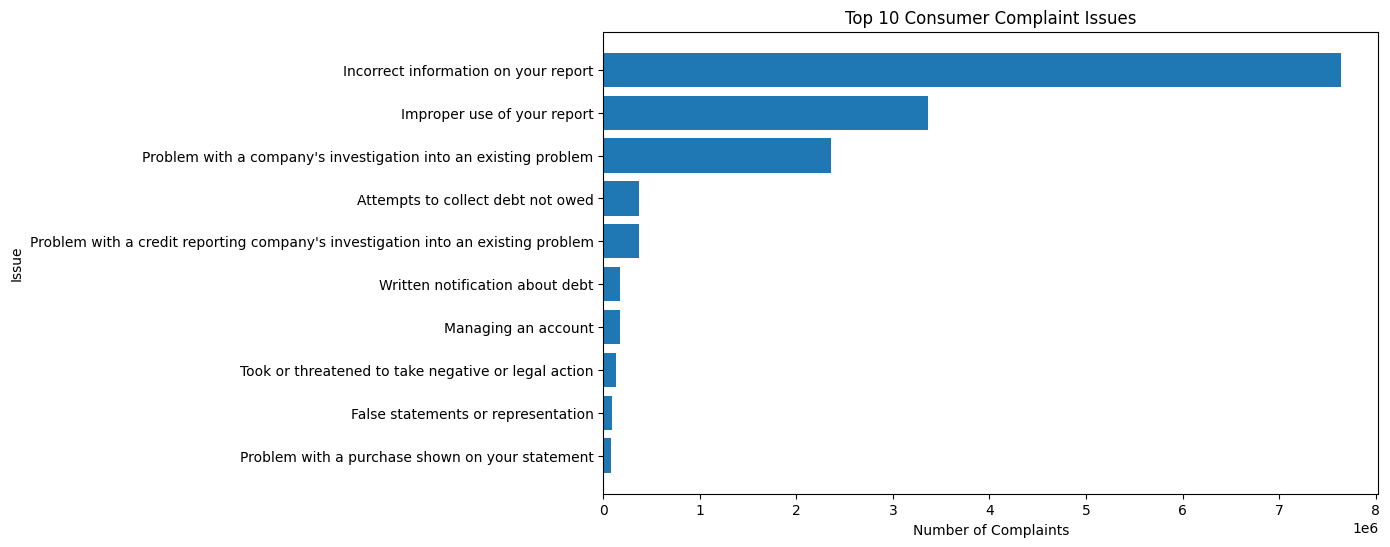

In [18]:
top_issues = issue_counts.head(10).sort_values("complaint_count")

plt.figure(figsize=(10, 6))

plt.barh(
    top_issues["issue"],
    top_issues["complaint_count"]
)

plt.title("Top 10 Consumer Complaint Issues")
plt.xlabel("Number of Complaints")
plt.ylabel("Issue")
plt.show()

**Product × Issue analysis**

In [19]:
product_issue = pd.crosstab(
    df["product"],
    df["issue"]
)

product_issue.shape

(14, 95)

In [20]:
product_issue_top = (
    df.groupby(["product", "issue"])
      .size()
      .reset_index(name="complaint_count")
      .sort_values(
          ["product", "complaint_count"],
          ascending=[True, False]
      )
)

product_issue_top.head(20)

,product,issue,complaint_count
4,Checking or savings account,Managing an account,169206
0,Checking or savings account,Closing an account,38802
9,Checking or savings account,Problem with a lender or other company chargin...,36279
5,Checking or savings account,Opening an account,26892
6,Checking or savings account,Problem caused by your funds being low,24017
3,Checking or savings account,Incorrect information on your report,831
7,Checking or savings account,Problem with a company's investigation into an...,495
2,Checking or savings account,Improper use of your report,242
10,Checking or savings account,Problem with fraud alerts or security freezes,174
1,Checking or savings account,Credit monitoring or identity theft protection...,131


**Company analysis**

In [21]:
company_counts = (
    df["company"]
    .value_counts()
    .reset_index()
)
company_counts.columns = ["company", "complaint_count"]

company_counts.head(20)

,company,complaint_count
0,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",4719196
1,"EQUIFAX, INC.",4446352
2,Experian Information Solutions Inc.,4115186
3,CAPITAL ONE FINANCIAL CORPORATION,114012
4,JPMORGAN CHASE & CO.,93732
5,WELLS FARGO & COMPANY,85624
6,"BANK OF AMERICA, NATIONAL ASSOCIATION",81766
7,"CITIBANK, N.A.",72814
8,"Block, Inc.",68362
9,LEXISNEXIS,63259


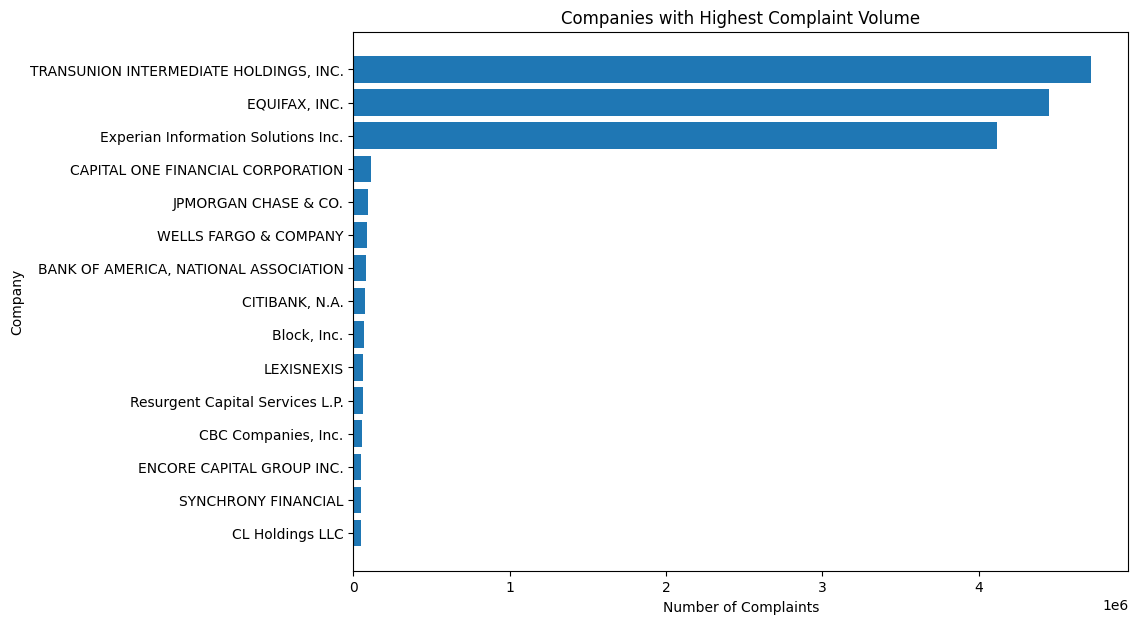

In [22]:
top_companies = company_counts.head(15).sort_values("complaint_count")

plt.figure(figsize=(10, 7))

plt.barh(
    top_companies["company"],
    top_companies["complaint_count"]
)

plt.title("Companies with Highest Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("Company")
plt.show()

**State analysis**

In [23]:
state_counts = (
    df["state"]
    .value_counts()
    .reset_index()
)
state_counts.columns = ["state", "complaint_count"]

state_counts.head(20)

,state,complaint_count
0,TX,2276814
1,FL,2222746
2,CA,1489764
3,GA,1197218
4,NY,887096
5,IL,684234
6,PA,609267
7,NC,551191
8,NJ,492905
9,AL,403475


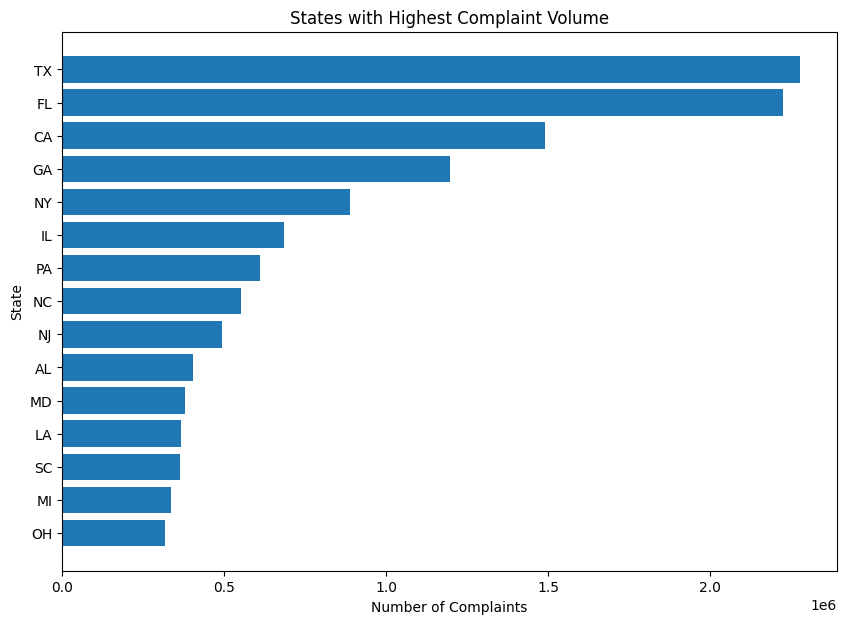

In [24]:
top_states = state_counts.head(15).sort_values("complaint_count")

plt.figure(figsize=(10, 7))

plt.barh(
    top_states["state"],
    top_states["complaint_count"]
)

plt.title("States with Highest Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("State")
plt.show()

**Submission channel**

In [25]:
submission_counts = (
    df["submitted_via"]
    .value_counts()
    .reset_index()
)
submission_counts.columns = ["submitted_via", "complaint_count"]

submission_counts

,submitted_via,complaint_count
0,Web,15550956
1,Phone,100323
2,Referral,60539
3,Postal mail,29796
4,Email,1


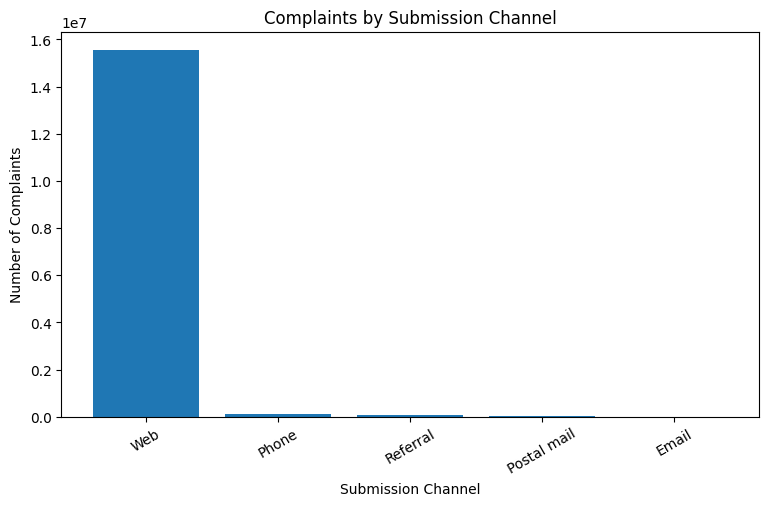

In [26]:
plt.figure(figsize=(9, 5))

plt.bar(
    submission_counts["submitted_via"],
    submission_counts["complaint_count"]
)

plt.title("Complaints by Submission Channel")
plt.xlabel("Submission Channel")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=30)
plt.show()

**Timely response analysis**

In [27]:
timely_counts = (
    df["timely_response"]
    .value_counts()
    .reset_index()
)
timely_counts.columns = ["timely_response", "complaint_count"]

timely_counts

,timely_response,complaint_count
0,Yes,15674923
1,No,66692


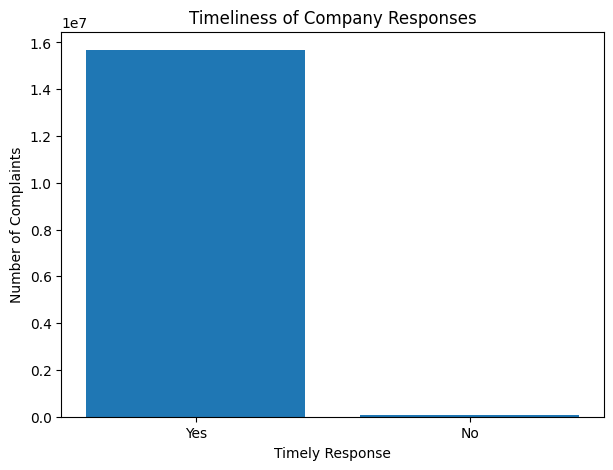

In [28]:
plt.figure(figsize=(7, 5))

plt.bar(
    timely_counts["timely_response"],
    timely_counts["complaint_count"]
)

plt.title("Timeliness of Company Responses")
plt.xlabel("Timely Response")
plt.ylabel("Number of Complaints")
plt.show()

**Company response analysis**

In [29]:
response_counts = (
    df["company_response_to_consumer"]
    .value_counts()
    .reset_index()
)
response_counts.columns = [
    "company_response_to_consumer",
    "complaint_count"
]

response_counts

,company_response_to_consumer,complaint_count
0,Closed with explanation,9172048
1,Closed with non-monetary relief,5797905
2,In progress,630221
3,Closed with monetary relief,114183
4,Untimely response,27238
5,Unknown,20


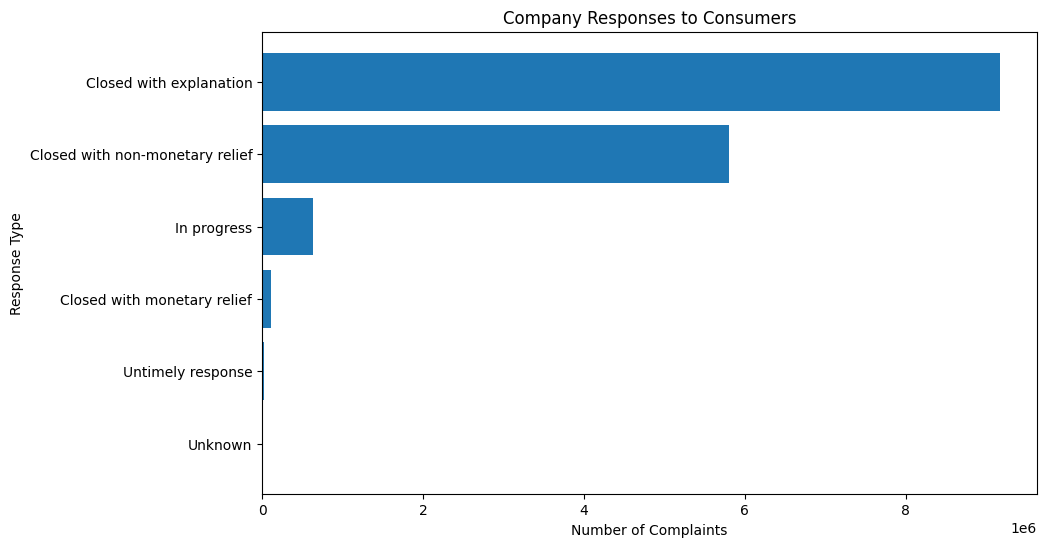

In [30]:
top_responses = response_counts.head(10).sort_values("complaint_count")

plt.figure(figsize=(10, 6))

plt.barh(
    top_responses["company_response_to_consumer"],
    top_responses["complaint_count"]
)

plt.title("Company Responses to Consumers")
plt.xlabel("Number of Complaints")
plt.ylabel("Response Type")
plt.show()

**Response time analysis**

In [31]:
df["response_days"].describe()

,response_days
count,1.574162e+07
mean,3.660844e-01
std,3.731059e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,9.150000e+02


In [32]:
valid_response = df[
    df["response_days"].between(0, 365)
]

print("Valid records:", len(valid_response))
print("Excluded from response-time analysis:",
      len(df) - len(valid_response))

Valid records: 15741593
Excluded from response-time analysis: 22


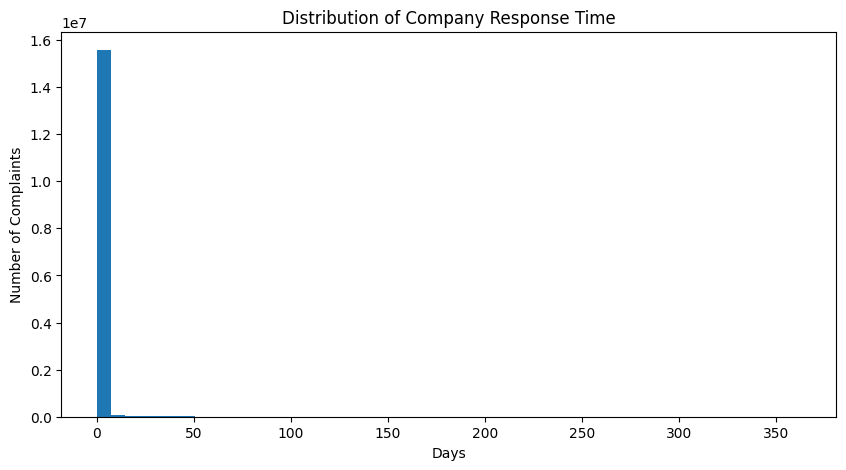

In [33]:
plt.figure(figsize=(10, 5))

plt.hist(
    valid_response["response_days"],
    bins=50
)

plt.title("Distribution of Company Response Time")
plt.xlabel("Days")
plt.ylabel("Number of Complaints")
plt.show()

**Key cross-analysis**

In [34]:
timely_by_product = pd.crosstab(
    df["product"],
    df["timely_response"],
    normalize="index"
) * 100

timely_by_product.round(2)

timely_response,No,Yes
product,,
Checking or savings account,0.84,99.16
Credit card,0.54,99.46
Credit card or prepaid card,1.11,98.89
Credit reporting or other personal consumer reports,0.10,99.90
"Credit reporting, credit repair services, or other personal consumer reports",0.19,99.81
Debt collection,2.85,97.15
Debt or credit management,8.58,91.42
"Money transfer, virtual currency, or money service",1.58,98.42
Mortgage,1.76,98.24


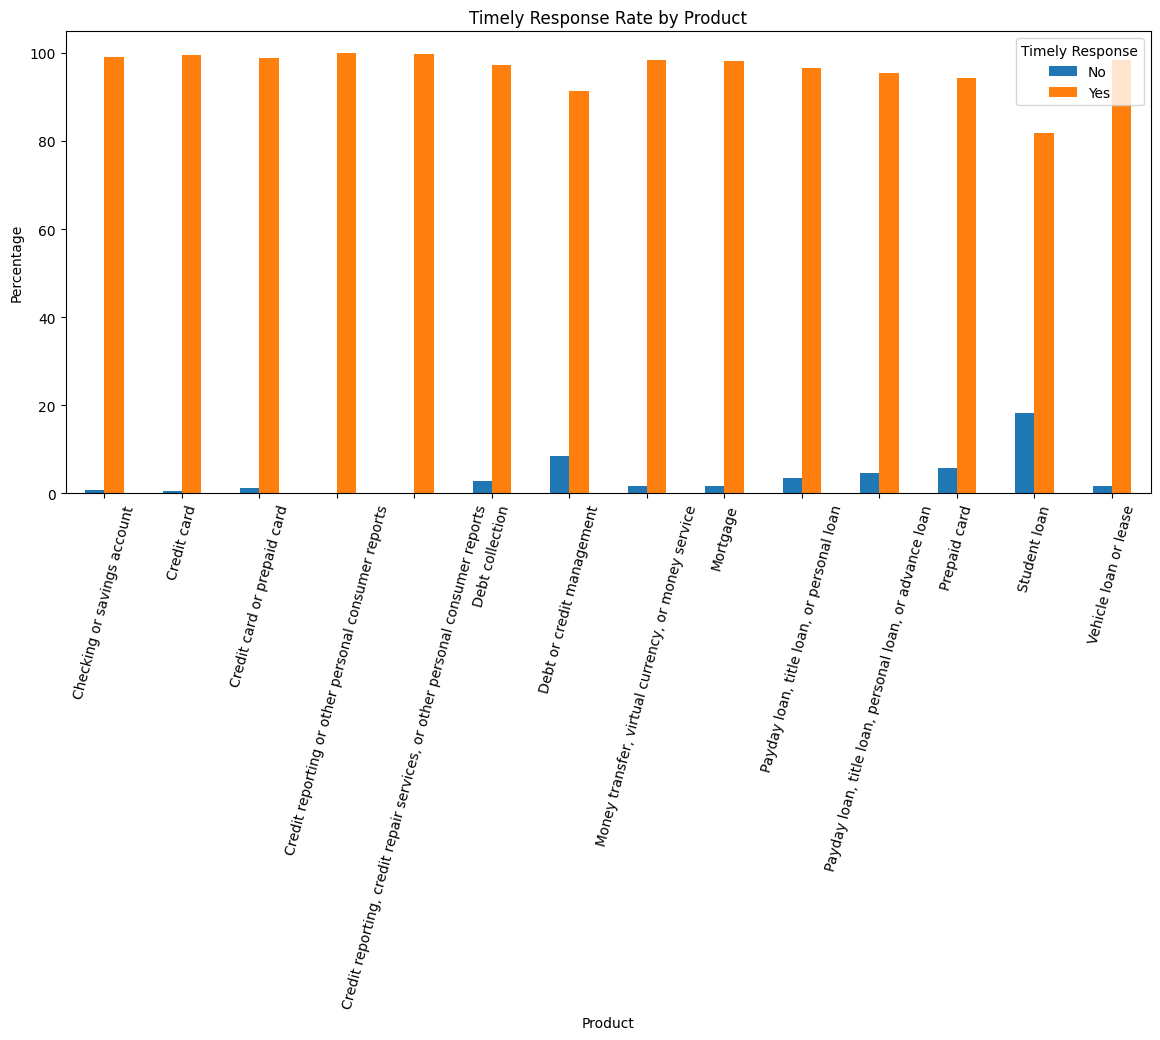

In [35]:
timely_by_product.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Timely Response Rate by Product")
plt.xlabel("Product")
plt.ylabel("Percentage")
plt.xticks(rotation=75)
plt.legend(title="Timely Response")
plt.show()